In [1]:
from astropy.table import Table
from common_functions import single_wavelet, plotter, reduce, read_sim, inject_flux
import butterpy as bp
import glob
import lightkurve as lk
from matplotlib import rc
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
from pyasassn.client import SkyPatrolClient

In [2]:
os.chdir(pathlib.Path.cwd())
def set_rcparams():
    tab = Table.read('rcparams.txt', format='csv')
    for i in range(len(tab)):
        try:
            plt.rcParams[tab['key'][i]] = float(tab['val'][i])
        except ValueError:
            plt.rcParams[tab['key'][i]] = str(tab['val'][i])
    return
set_rcparams()

In [3]:
client = SkyPatrolClient()
def pipeline(objid):
    lcs = client.query_list([objid], download=True)
    for lc in lcs.itercurves():
        savedlc = lc
    savedlc_fin = reduce(savedlc)
    wavelet = single_wavelet(savedlc_fin, savedlc_fin.data.flux)
    plotter(wavelet, True)
    return(savedlc_fin)

Welcome to ASAS-SN Skypatrol!

Current Deployment Version: 0.6.19 (22 MAY 2025)
Please upgrade your client if not up to date.

We are reprocessing a number of lightcurves in database.
Once finished we should have more complete and higher quality photometry.
Thank you for your patience,
K. Hart (22 MAY 2025)




Pulled 1 of 1


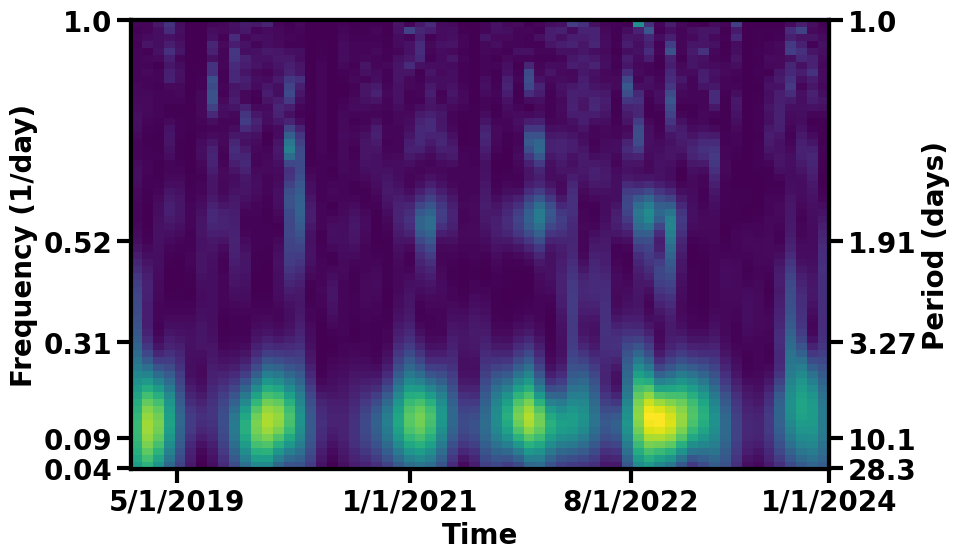

In [4]:
lcsave = pipeline(463856975202)

In [5]:
simulation_file = glob.glob("files/sim900184.fits")
simulation = read_sim(simulation_file[0])
newflux = inject_flux(simulation, lcsave)

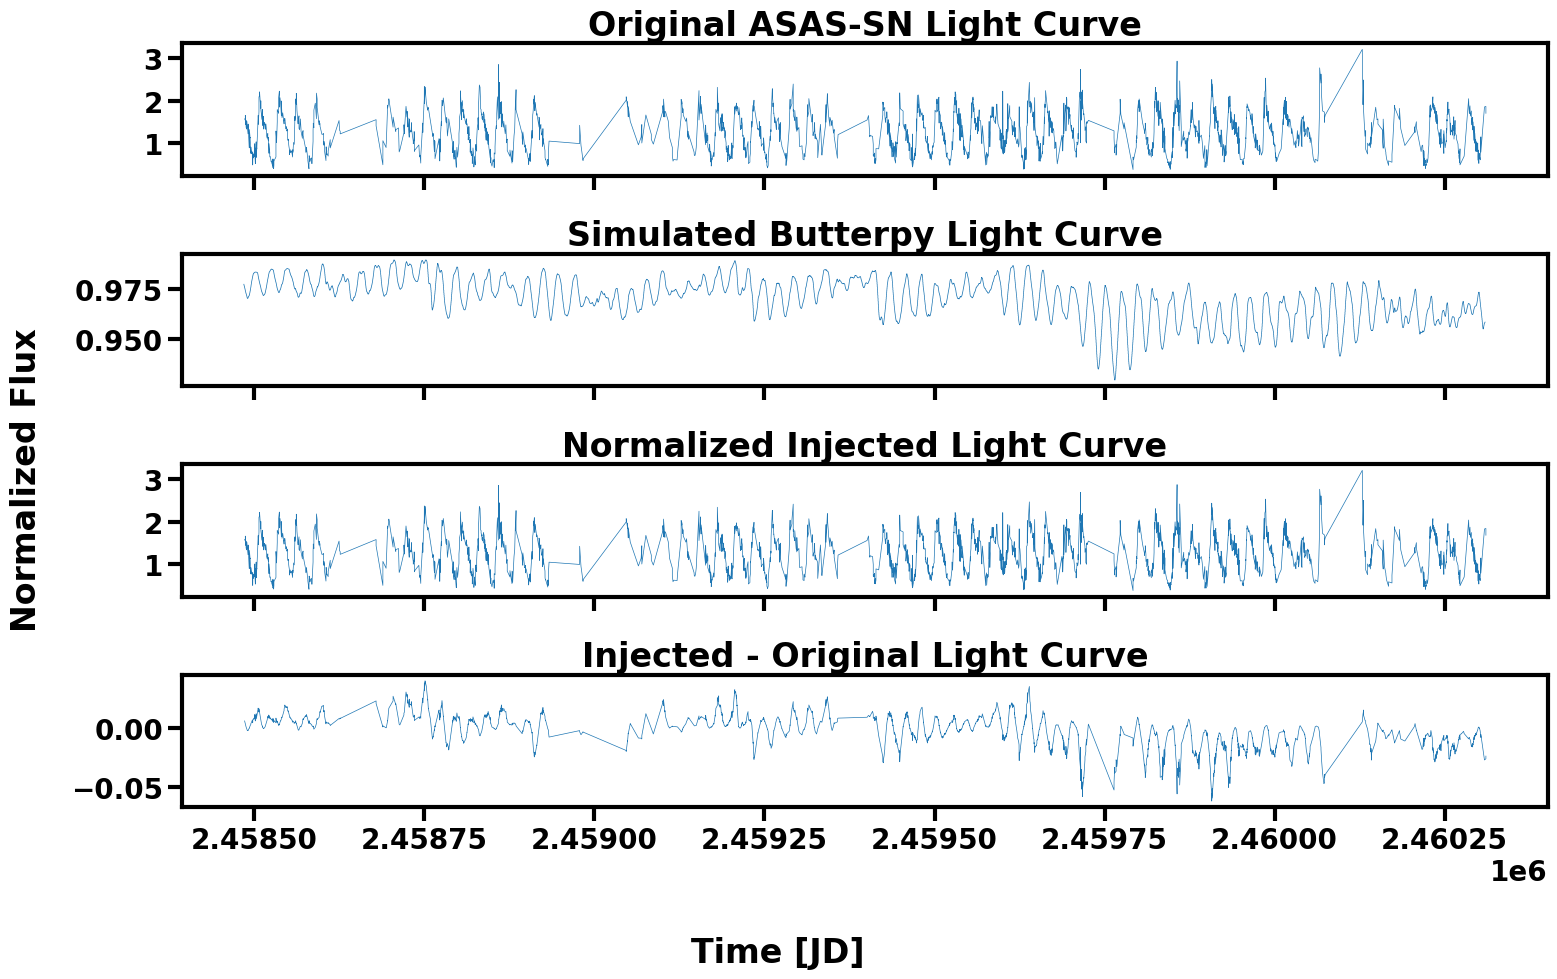

In [6]:
rc('font', weight='bold')

fig, [ax1, ax2, ax3, ax4] = plt.subplots(figsize=(16, 10), ncols = 1, nrows = 4, sharex=True)

ax1.set_title("Original ASAS-SN Light Curve", weight='bold')
noiseylc = lk.LightCurve(time=lcsave.jd, flux=lcsave.flux)
noiseylc.plot(ax=ax1, xlabel="", ylabel="", rasterized=True)

ax2.set_title("Simulated Butterpy Light Curve", weight='bold')
new_sim_lc = lk.LightCurve(time=simulation.time, flux=simulation.flux)
new_sim_lc.plot(ax = ax2, xlabel="", ylabel="", rasterized=True)

ax3.set_title("Normalized Injected Light Curve", weight='bold')
new_sim_lc2 = lk.LightCurve(time=lcsave.jd, flux=newflux)
new_sim_lc2.plot(ax = ax3, xlabel="", ylabel="", rasterized=True)

ax4.set_title("Injected - Original Light Curve", weight='bold')
new_sim_lc3 = lk.LightCurve(time=lcsave.jd, flux=(newflux-lcsave.flux))
new_sim_lc3.plot(ax = ax4, xlabel="", ylabel="", rasterized=True)

fig.supylabel('Normalized Flux', weight='bold')
fig.supxlabel('Time [JD]', weight='bold')
plt.tight_layout()
#plt.savefig('lc+inject.pdf')